In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import sys; sys.path.append("../utils")
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

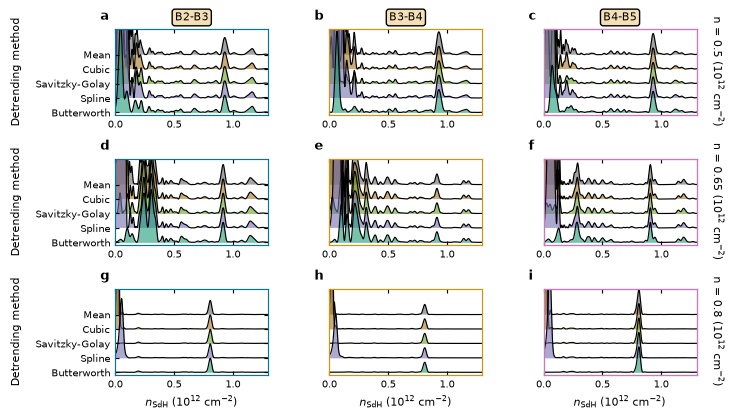

In [2]:
from typing import Optional, Tuple, Any
from dataclasses import dataclass


@dataclass
class JoyPlotConfig:
    """Configuration for joy plot appearance."""
    x_range: Optional[Tuple[float, float]] = None
    overlap: float = 2.0          # ridge height in units of row spacing
    clip: Optional[float] = None  # max normalized amplitude (None = no clip)
    y_scale: float = 1.0          # vertical spacing between rows
    cmap: Any = None              # colormap (defaults to viridis)
    fill_alpha: float = 0.7
    line_color: str = 'k'
    line_width: float = 1.0
    normalize: bool = True        # normalize each row
    log_scale: bool = False       # use log scale for amplitudes
    
    def __post_init__(self):
        if self.cmap is None:
            self.cmap = plt.cm.viridis


def plot_joyplot(
    fig: plt.Figure,
    ax: plt.Axes,
    xdata: list,
    ydata: list,
    labels: list,
    config: Optional[JoyPlotConfig] = None,
) -> None:
    """
    Create a joy plot (ridgeline plot) on existing axes.
    
    Parameters
    ----------
    fig : plt.Figure
        Figure object
    ax : plt.Axes
        Axes to plot on
    xdata : list of np.ndarray
        List of x-arrays, one per ridge. Can have different lengths.
    ydata : list of np.ndarray
        List of y-arrays (amplitudes), one per ridge. Can have different lengths.
    labels : list of str
        Labels for each ridge (used for y-axis ticks and coloring)
    config : JoyPlotConfig, optional
        Appearance configuration
    """
    config = config or JoyPlotConfig()
    n_rows = len(xdata)
    
    if len(ydata) != n_rows or len(labels) != n_rows:
        raise ValueError("xdata, ydata, and labels must have same length")
    
    # Plot each row
    for i in range(n_rows):
        x = np.asarray(xdata[i])
        y = np.asarray(ydata[i]).copy()
        
        # Apply x_range filter if specified
        if config.x_range is not None:
            x_min, x_max = config.x_range
            mask = (x >= x_min) & (x <= x_max)
            x = x[mask]
            y = y[mask]
        
                # Normalize amplitude
        if config.normalize:
            y_max = np.nanmax(np.abs(y))
            y = y / y_max
 
        # Ensure non-negative for filling
        y = np.maximum(y, 0)
        
        # Calculate baseline and color
        base = i * config.y_scale
        color = config.cmap(i / max(1, n_rows - 1))
        
        # Plot filled ridge
        ax.fill_between(
            x, base, base + config.overlap * y,
            color=color,
            alpha=config.fill_alpha,
            zorder=-i * 2,
            linewidth=0
        )
        
        # Plot ridge outline
        ax.plot(
            x, base + config.overlap * y,
            color=config.line_color,
            lw=config.line_width,
            zorder=-i * 2 + 1,
            clip_on=True
        )
    
    # Set axis limits
    if config.x_range is not None:
        ax.set_xlim(*config.x_range)
    
    # Set y-axis
    ax.set_ylim(-0.2 * config.y_scale, (n_rows - 1 + config.overlap * 1.2) * config.y_scale)
    ax.set_yticks(np.arange(n_rows) * config.y_scale)
    ax.set_yticklabels(labels)


##### MAIN CODE ##### 

detrends = {
    'Mean': [lambda y, x: (x-np.mean(x), 0), {}],
    'Cubic': [detrend_poly, {'degree': 3}],
    'Savitzky-Golay': [detrend_savgol, {'win':101, 'poly':3, 'max_win_frac':0.4}],
    'Spline': [detrend_spline, {'n_knots': 10}],
    'Butterworth': [detrend_butterworth, {'cutoff': None, 'order': 4}]
}

n_panels = len(contact_names.keys())
target_densities = [0.5, 0.65, 0.8]
n_methods = len(detrends)

fig = plt.figure(figsize=(7.5, 4.5))
gs = GridSpec(len(target_densities), n_panels, wspace=0.4, hspace=0.5)
axes = [[fig.add_subplot(gs[i, j]) for i in range(len(target_densities))] for j in range(n_panels)]
axes = np.array(axes)

letters = list(map(chr, range(97, 97+26)))

# Joy plot configuration
detrend_colors = plt.get_cmap('Dark2')

y_scales = [2e-5, 2e-6, 2e-3]

for i, (contact_idx, contact_name) in enumerate(contact_names.items()):
    analyzer = Lf_analysis(1840, contact=contact_idx)
    
    for j, target_density in enumerate(target_densities):
        ax = axes[i, j]
        
        pos = ax.get_position()
        fig.text(pos.x0 - 0.02, pos.y1 + 0.02, letters[j*n_panels+i], fontweight='bold')
        
        # Collect data for all detrending methods
        freq_data = []
        psd_data = []
        method_names = []
        
        for method_name, method in detrends.items():
            detrend_func, kwargs = method
            psd, freq = analyzer.get_fft_line(
                target_density, 
                bg_method=detrend_func, 
                bg_method_params=kwargs, 
                padding=8, 
                blims=(0.62, 4.98)
            )
            freq = freq * target_density  # convert to n_SdH
            
            freq_data.append(freq)
            psd_data.append(psd)
            method_names.append(method_name)
        
        # Convert to arrays (assume same frequency grid)
        method_names = method_names[::-1]  # reverse for correct order in joy plot
        freq_array = np.array(freq_data[::-1])
        psd_array = np.array(psd_data[::-1]) / np.max(psd_data)  # normalize for coloring
        z_array = np.arange(n_methods)  # for coloring
        config = JoyPlotConfig(
            x_range=(0, 1.3),
            overlap=1.5,           # adjust to control ridge height
            clip=5.0,              # adjust to prevent collisions
            y_scale=y_scales[j],           # adjust vertical spacing
            cmap=detrend_colors,
            fill_alpha=0.6,
            line_width=0.85,
            normalize=False 
        )
        # Plot joy plot
        plot_joyplot(fig, ax, freq_array, psd_array, z_array, config)
        
        # Set labels and formatting
        if j == 0:
            ax.set_title(
                contact_name,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="#f5dfb4",
                    edgecolor="k",
                    linewidth=1,
                    alpha=1,
                )
            )
        if j == len(target_densities) - 1:
            ax.set_xlabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
        if i == 0:
            ax.set_ylabel('Detrending method', labelpad=10.0)
            # Set yticks to method names
            ax.set_yticks(np.arange(n_methods) * config.y_scale)
            ax.set_yticklabels(method_names)
        else:
            ax.set_yticks([])
            
        if i == n_panels - 1:
            n_unit = r'$10^{12}$ cm$^{-2}$'
            ax_right = ax.twinx()
            ax_right.set_ylim(ax.get_ylim())
            ax_right.set_yticks([])
            ax_right.set_ylabel(
                rf'n = {target_density} ({n_unit})', 
                labelpad=20.0, 
                rotation=270,
            )
            for spine in ax_right.spines.values():
                spine.set_edgecolor(contact_colors_idx[contact_idx])

        for spine in ax.spines.values():
            spine.set_edgecolor(contact_colors_idx[contact_idx])
            

plt.savefig('figS_FFT_compare_bgsub_cuts.pdf', 
            dpi=600,
            bbox_inches='tight',
            pad_inches=0.08, transparent=False)